In [ ]:
# Install packages (only needed first time)
!pip install numpy scipy scikit-learn matplotlib networkx

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.covariance import MinCovDet, GraphicalLasso
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import KMeans
from scipy.spatial.distance import mahalanobis



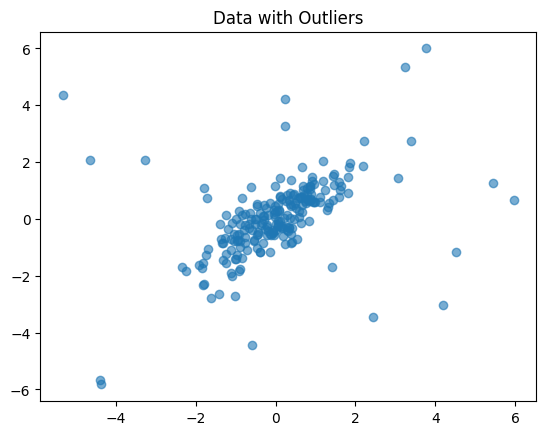

In [ ]:
# -------------------------
# 1) Generate data + outliers
# -------------------------
np.random.seed(42)

n_samples = 200
mean = [0, 0]
cov = [[1, 0.8], [0.8, 1]]

X = np.random.multivariate_normal(mean, cov, n_samples)

outliers = np.random.uniform(low=-6, high=6, size=(20, 2))
X_full = np.vstack([X, outliers])

plt.scatter(X_full[:, 0], X_full[:, 1], alpha=0.6)
plt.title("Data with Outliers")
plt.show()



In [ ]:
# -------------------------
# 2) Robust covariance (MCD)
# -------------------------
mcd = MinCovDet().fit(X_full)
robust_mean = mcd.location_
robust_cov = mcd.covariance_

print("Robust Mean:\n", robust_mean)
print("Robust Covariance:\n", robust_cov)



Robust Mean:
 [0.00328314 0.0242294 ]
Robust Covariance:
 [[0.75118613 0.59663518]
 [0.59663518 0.77212811]]


In [ ]:
# -------------------------
# 3) Precision matrix
# -------------------------
precision_matrix = np.linalg.inv(robust_cov)
print("Precision Matrix:\n", precision_matrix)



Precision Matrix:
 [[ 3.4464098  -2.66309346]
 [-2.66309346  3.35293484]]


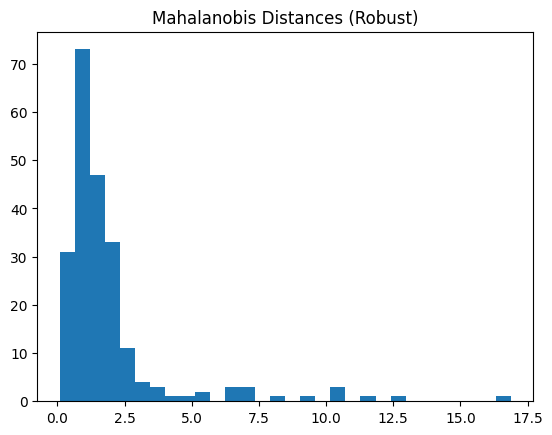

In [ ]:
# -------------------------
# 4) Mahalanobis distances
# -------------------------
def mahalanobis_distances(X, mean, precision):
    return np.array([mahalanobis(x, mean, precision) for x in X])

dists = mahalanobis_distances(X_full, robust_mean, precision_matrix)

plt.hist(dists, bins=30)
plt.title("Mahalanobis Distances (Robust)")
plt.show()

# Outlier filtering
threshold = np.percentile(dists, 95)
inliers = X_full[dists < threshold]



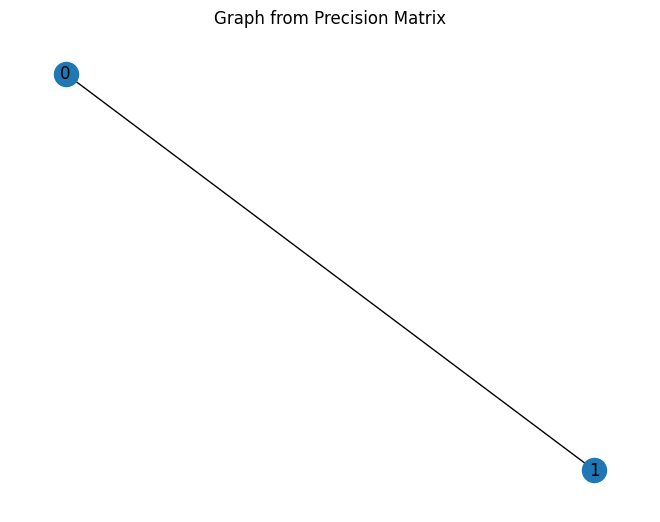

In [ ]:
# -------------------------
# 5) Graph from precision matrix
# -------------------------
G = nx.Graph()
n_features = precision_matrix.shape[0]

for i in range(n_features):
    for j in range(i + 1, n_features):
        weight = precision_matrix[i, j]
        if abs(weight) > 1e-3:
            G.add_edge(i, j, weight=weight)

nx.draw(G, with_labels=True)
plt.title("Graph from Precision Matrix")
plt.show()



Laplacian shape: (209, 209)


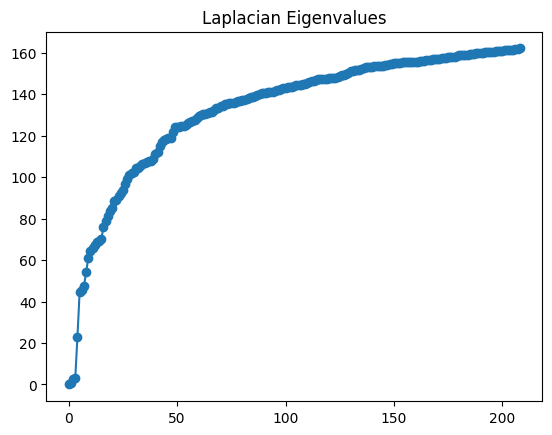

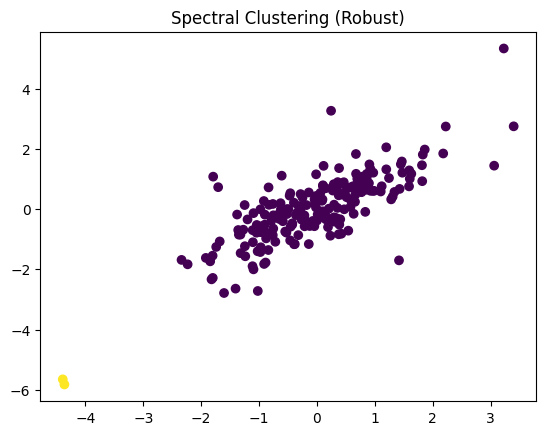

Sparse Precision Matrix:
 [[ 0.60370108 -0.2331324 ]
 [-0.2331324   0.6008536 ]]


In [ ]:
# -------------------------
# 6) Graph from data (distance-based)
# -------------------------
dist_matrix = euclidean_distances(inliers)

sigma = np.mean(dist_matrix)
A = np.exp(-dist_matrix**2 / (2 * sigma**2))
np.fill_diagonal(A, 0)

# -------------------------
# 7) Laplacian
# -------------------------
D = np.diag(A.sum(axis=1))
L = D - A

print("Laplacian shape:", L.shape)

# -------------------------
# 8) Spectral analysis
# -------------------------
eigenvalues, eigenvectors = np.linalg.eigh(L)

plt.plot(eigenvalues, 'o-')
plt.title("Laplacian Eigenvalues")
plt.show()

# -------------------------
# 9) Spectral clustering
# -------------------------
k = 2
X_spec = eigenvectors[:, :k]

kmeans = KMeans(n_clusters=k, n_init=10)
labels = kmeans.fit_predict(X_spec)

plt.scatter(inliers[:, 0], inliers[:, 1], c=labels, cmap='viridis')
plt.title("Spectral Clustering (Robust)")
plt.show()

# -------------------------
# 10) Sparse precision (Graphical Lasso)
# -------------------------
model = GraphicalLasso(alpha=0.1)
model.fit(X_full)

sparse_precision = model.precision_
print("Sparse Precision Matrix:\n", sparse_precision)



/tmp/ipykernel_7404/2825890961.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2018-01-01", end="2024-12-31")["Close"]
[*********************100%***********************]  30 of 30 completed


Assets used: 30


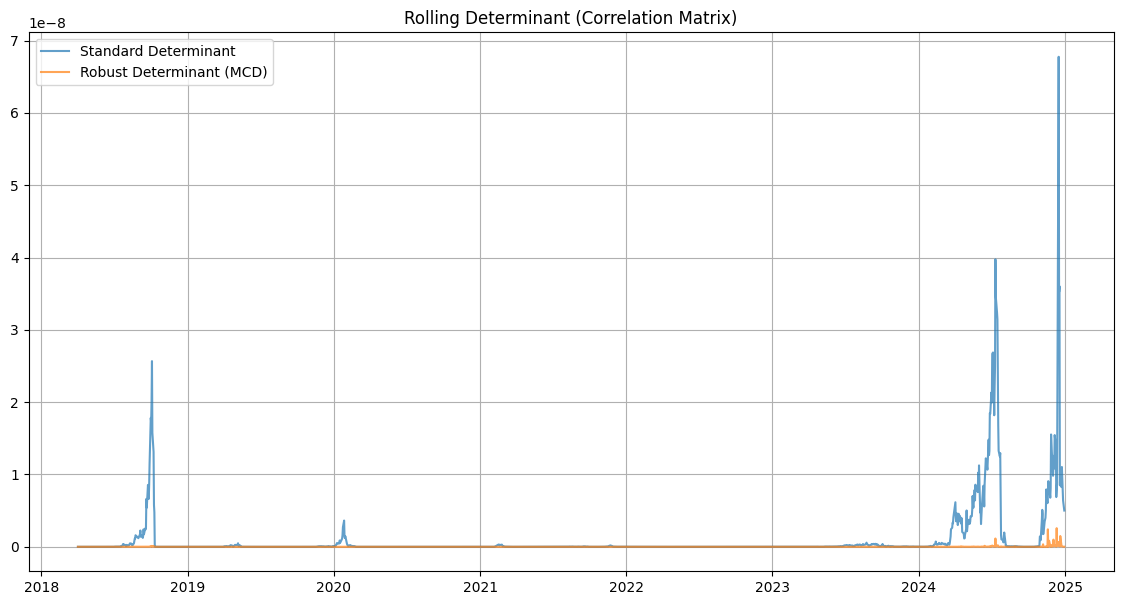

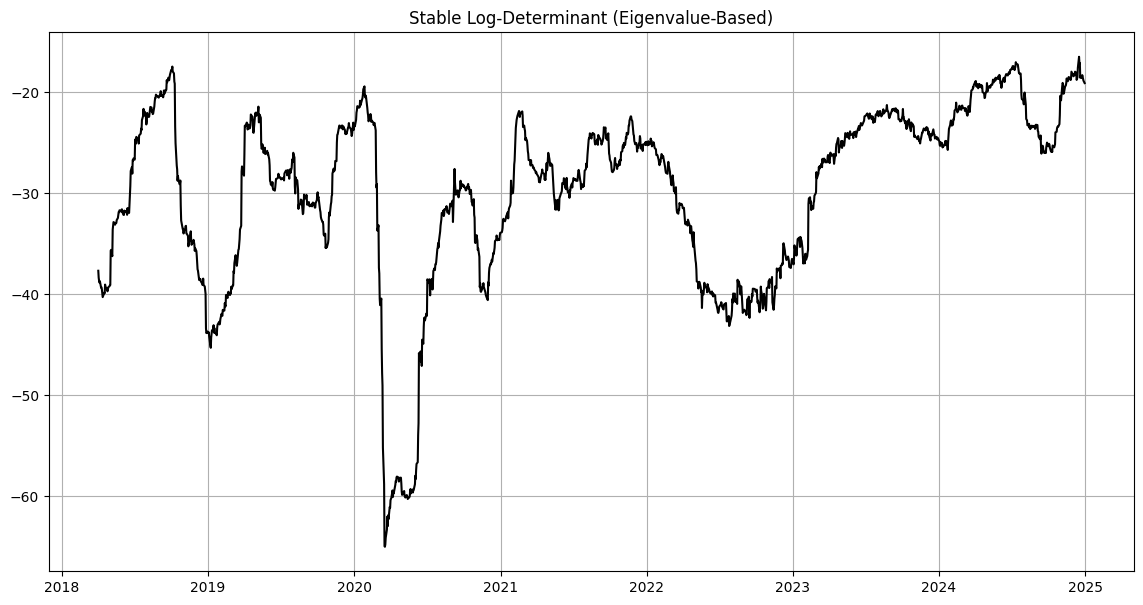

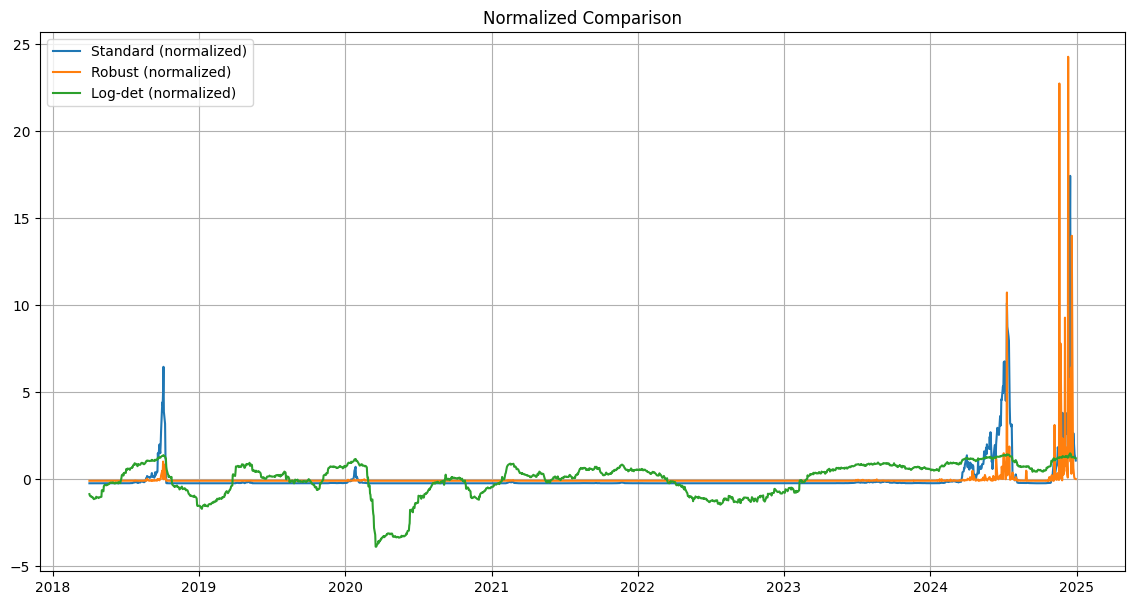

In [ ]:
# ============================================
# FULL PIPELINE: STANDARD + ROBUST + LOG-DET
# ============================================

!pip install yfinance pandas numpy matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.covariance import MinCovDet

# -------------------------
# 1) Select 30 stocks
# -------------------------
tickers = [
    "AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","JPM","V","MA",
    "UNH","HD","PG","DIS","KO","PEP","XOM","CVX","ABBV","MRK",
    "PFE","TMO","CSCO","AVGO","COST","WMT","ADBE","NFLX","INTC","CRM"
]

# -------------------------
# 2) Download data
# -------------------------
data = yf.download(tickers, start="2018-01-01", end="2024-12-31")["Close"]
data = data.dropna(axis=1)

print("Assets used:", data.shape[1])

# -------------------------
# 3) Log returns
# -------------------------
returns = np.log(data / data.shift(1)).dropna()

# -------------------------
# 4) Rolling settings
# -------------------------
window = 60

det_standard = []
logdet_stable = []
det_robust = []
dates = []

# -------------------------
# 5) Rolling computation
# -------------------------
for i in range(window, len(returns)):
    window_data = returns.iloc[i-window:i].values

    # ----- STANDARD CORRELATION -----
    corr_matrix = np.corrcoef(window_data, rowvar=False)

    # determinant
    det = np.linalg.det(corr_matrix)
    det_standard.append(det)

    # ----- STABLE LOG-DET via eigenvalues -----
    eigvals = np.linalg.eigvalsh(corr_matrix)
    eigvals = np.clip(eigvals, 1e-10, None)  # avoid log(0)
    logdet = np.sum(np.log(eigvals))
    logdet_stable.append(logdet)

    # ----- ROBUST (MCD) -----
    try:
        mcd = MinCovDet().fit(window_data)
        cov = mcd.covariance_

        std = np.sqrt(np.diag(cov))
        corr_robust = cov / np.outer(std, std)

        det_r = np.linalg.det(corr_robust)
    except:
        det_r = np.nan

    det_robust.append(det_r)
    dates.append(returns.index[i])

# -------------------------
# 6) Convert to series
# -------------------------
det_standard = pd.Series(det_standard, index=dates)
logdet_stable = pd.Series(logdet_stable, index=dates)
det_robust = pd.Series(det_robust, index=dates)

# -------------------------
# 7) Plot comparison
# -------------------------
plt.figure(figsize=(14,7))
plt.plot(det_standard, label="Standard Determinant", alpha=0.7)
plt.plot(det_robust, label="Robust Determinant (MCD)", alpha=0.7)
plt.title("Rolling Determinant (Correlation Matrix)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# 8) Plot stable log-det
# -------------------------
plt.figure(figsize=(14,7))
plt.plot(logdet_stable, color='black')
plt.title("Stable Log-Determinant (Eigenvalue-Based)")
plt.grid(True)
plt.show()

# -------------------------
# 9) Optional normalization (better comparison)
# -------------------------
def normalize(series):
    return (series - series.mean()) / series.std()

plt.figure(figsize=(14,7))
plt.plot(normalize(det_standard), label="Standard (normalized)")
plt.plot(normalize(det_robust), label="Robust (normalized)")
plt.plot(normalize(logdet_stable), label="Log-det (normalized)")
plt.legend()
plt.title("Normalized Comparison")
plt.grid(True)
plt.show()



/tmp/ipykernel_7404/2747079967.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2018-01-01", end="2024-12-31")["Close"]
[*********************100%***********************]  30 of 30 completed


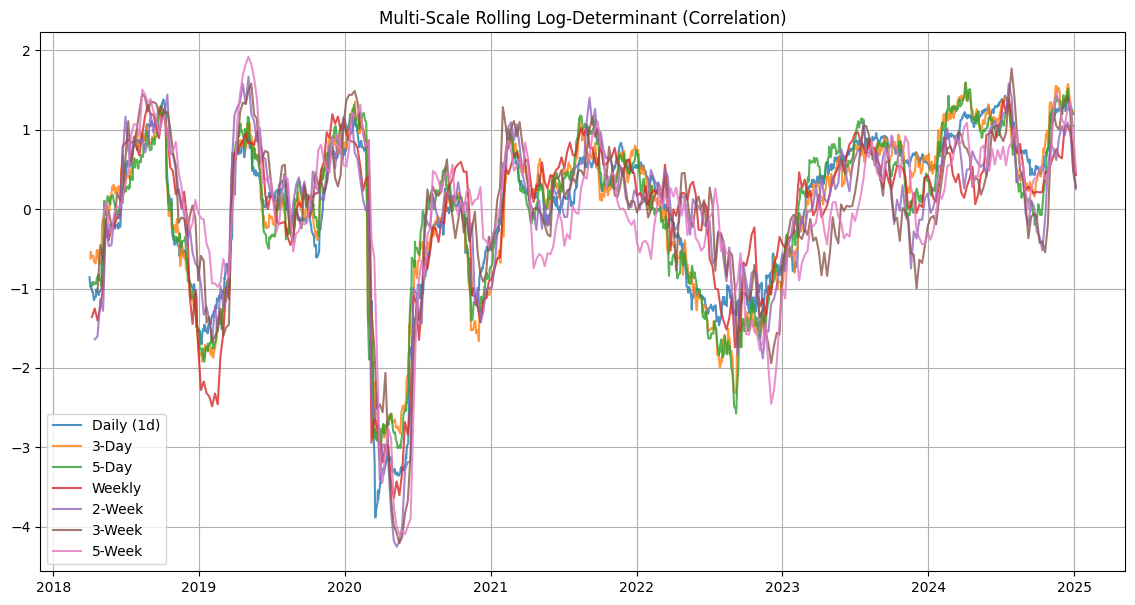

In [ ]:

# ============================================
# MULTI-SCALE ROLLING DETERMINANT PIPELINE
# (Daily, k-day, Weekly, k-week)
# ============================================

!pip install yfinance pandas numpy matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.covariance import MinCovDet

# -------------------------
# 1) Stock universe (30 assets)
# -------------------------
tickers = [
    "AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","JPM","V","MA",
    "UNH","HD","PG","DIS","KO","PEP","XOM","CVX","ABBV","MRK",
    "PFE","TMO","CSCO","AVGO","COST","WMT","ADBE","NFLX","INTC","CRM"
]

# -------------------------
# 2) Download data
# -------------------------
data = yf.download(tickers, start="2018-01-01", end="2024-12-31")["Close"]
data = data.dropna(axis=1)

# -------------------------
# 3) RETURN FUNCTIONS
# -------------------------
def log_returns(prices, lag=1):
    return np.log(prices / prices.shift(lag)).dropna()

# Daily returns
returns_daily = log_returns(data, lag=1)

# Multi-day returns (e.g. 3-day and 5-day)
returns_3d = log_returns(data, lag=3)
returns_5d = log_returns(data, lag=5)

# Weekly prices → weekly returns
weekly_prices = data.resample("W").last()
returns_weekly = log_returns(weekly_prices, lag=1)

# Multi-week returns (2–5 weeks)
returns_2w = log_returns(weekly_prices, lag=2)
returns_3w = log_returns(weekly_prices, lag=3)
returns_5w = log_returns(weekly_prices, lag=5)

# -------------------------
# 4) Rolling determinant function
# -------------------------
def rolling_det(returns, window=60, robust=False):
    dets = []
    dates = []

    for i in range(window, len(returns)):
        window_data = returns.iloc[i-window:i].values

        try:
            if robust:
                mcd = MinCovDet().fit(window_data)
                cov = mcd.covariance_
                std = np.sqrt(np.diag(cov))
                corr = cov / np.outer(std, std)
            else:
                corr = np.corrcoef(window_data, rowvar=False)

            # stable log-det via eigenvalues
            eigvals = np.linalg.eigvalsh(corr)
            eigvals = np.clip(eigvals, 1e-10, None)
            logdet = np.sum(np.log(eigvals))

        except:
            logdet = np.nan

        dets.append(logdet)
        dates.append(returns.index[i])

    return pd.Series(dets, index=dates)

# -------------------------
# 5) Compute signals
# -------------------------
window = 60

signals = {
    "Daily (1d)": rolling_det(returns_daily, window),
    "3-Day": rolling_det(returns_3d, window),
    "5-Day": rolling_det(returns_5d, window),
    "Weekly": rolling_det(returns_weekly, window//5),
    "2-Week": rolling_det(returns_2w, window//5),
    "3-Week": rolling_det(returns_3w, window//5),
    "5-Week": rolling_det(returns_5w, window//5),
}

# -------------------------
# 6) Plot comparison
# -------------------------
plt.figure(figsize=(14,7))

for label, series in signals.items():
    series_norm = (series - series.mean()) / series.std()
    plt.plot(series_norm, label=label, alpha=0.8)

plt.title("Multi-Scale Rolling Log-Determinant (Correlation)")
plt.legend()
plt.grid(True)
plt.show()



/tmp/ipykernel_7404/847366193.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2018-01-01", end="2024-12-31")["Close"]
[*********************100%***********************]  30 of 30 completed


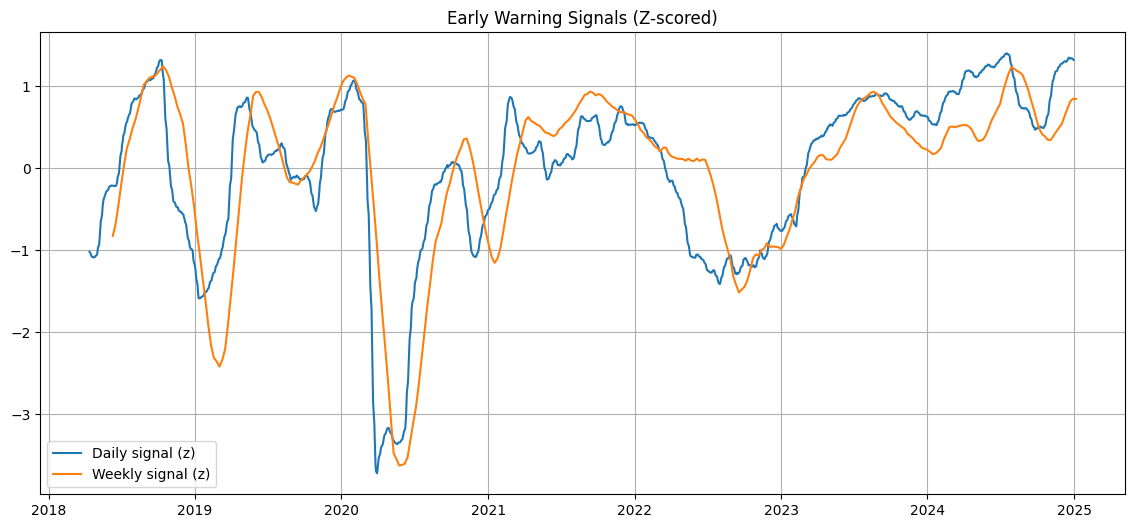

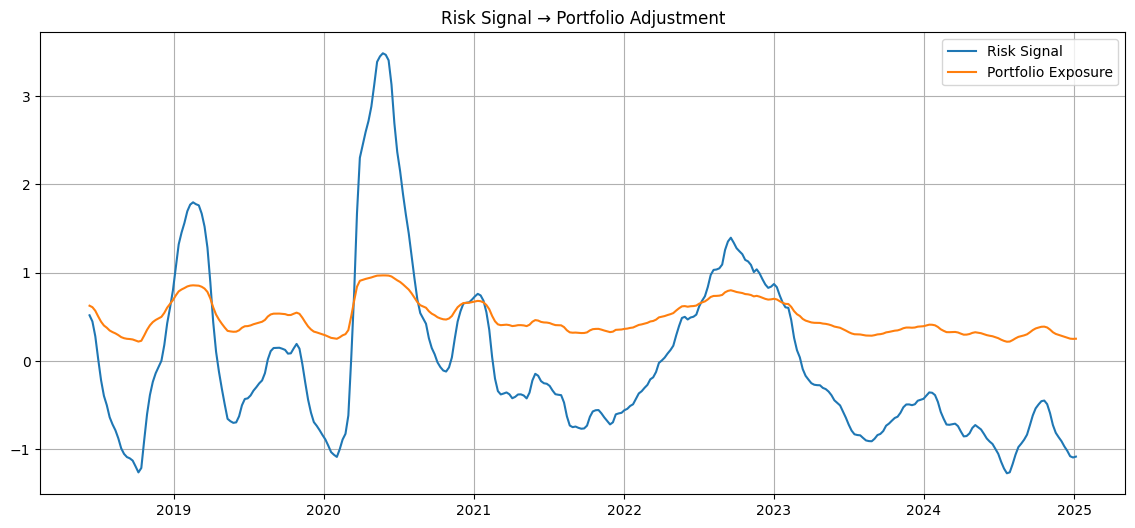

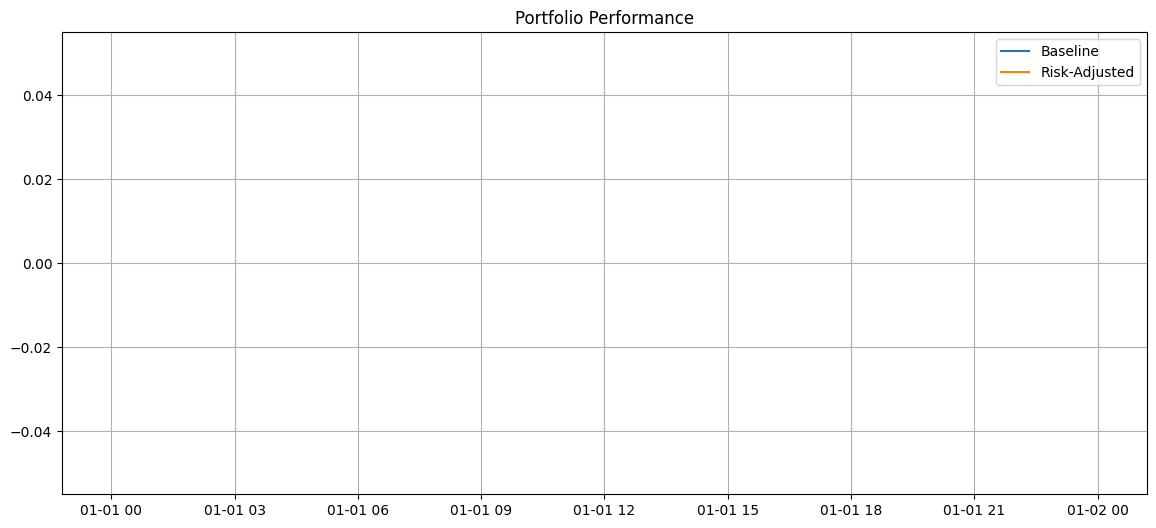

In [ ]:

# ============================================
# EARLY WARNING SIGNAL + PORTFOLIO ADJUSTMENT
# ============================================

!pip install yfinance pandas numpy matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.covariance import MinCovDet

# -------------------------
# 1) Data
# -------------------------
tickers = [
    "AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","JPM","V","MA",
    "UNH","HD","PG","DIS","KO","PEP","XOM","CVX","ABBV","MRK",
    "PFE","TMO","CSCO","AVGO","COST","WMT","ADBE","NFLX","INTC","CRM"
]

data = yf.download(tickers, start="2018-01-01", end="2024-12-31")["Close"]
data = data.dropna(axis=1)

# -------------------------
# 2) Returns
# -------------------------
def log_returns(prices, lag=1):
    return np.log(prices / prices.shift(lag)).dropna()

returns_daily = log_returns(data, 1)
returns_weekly = log_returns(data.resample("W").last(), 1)

# -------------------------
# 3) Rolling log-det
# -------------------------
def rolling_logdet(returns, window, robust=False):
    vals, dates = [], []

    for i in range(window, len(returns)):
        X = returns.iloc[i-window:i].values

        try:
            if robust:
                mcd = MinCovDet().fit(X)
                cov = mcd.covariance_
                std = np.sqrt(np.diag(cov))
                corr = cov / np.outer(std, std)
            else:
                corr = np.corrcoef(X, rowvar=False)

            eigvals = np.linalg.eigvalsh(corr)
            eigvals = np.clip(eigvals, 1e-10, None)
            logdet = np.sum(np.log(eigvals))

        except:
            logdet = np.nan

        vals.append(logdet)
        dates.append(returns.index[i])

    return pd.Series(vals, index=dates)

# Signals (multi-scale)
ld_daily = rolling_logdet(returns_daily, 60)
ld_weekly = rolling_logdet(returns_weekly, 12)

# -------------------------
# 4) Early warning features
# -------------------------
def compute_ews(signal):
    # Smooth
    smooth = signal.rolling(10).mean()

    # Z-score
    z = (smooth - smooth.mean()) / smooth.std()

    # Trend (slope)
    trend = smooth.diff(5)

    return smooth, z, trend

smooth_d, z_d, trend_d = compute_ews(ld_daily)
smooth_w, z_w, trend_w = compute_ews(ld_weekly)

# -------------------------
# 5) Combine signals
# -------------------------
combined_signal = (z_d.reindex(z_w.index, method='ffill') + z_w) / 2

# Risk signal: low value = danger
risk_signal = -combined_signal

# -------------------------
# 6) Portfolio scaling rule
# -------------------------
# Map signal → exposure (0 to 1)
def exposure(signal):
    return 1 / (1 + np.exp(-signal))  # sigmoid

weights = exposure(risk_signal)

# -------------------------
# 7) Example portfolio return
# -------------------------
portfolio_returns = returns_daily.mean(axis=1)  # equal-weight baseline
portfolio_returns = portfolio_returns.reindex(weights.index)

adjusted_returns = portfolio_returns * weights

# -------------------------
# 8) Plot signals
# -------------------------
plt.figure(figsize=(14,6))
plt.plot(z_d, label="Daily signal (z)")
plt.plot(z_w, label="Weekly signal (z)")
plt.legend()
plt.title("Early Warning Signals (Z-scored)")
plt.grid(True)
plt.show()

# -------------------------
# 9) Plot risk & exposure
# -------------------------
plt.figure(figsize=(14,6))
plt.plot(risk_signal, label="Risk Signal")
plt.plot(weights, label="Portfolio Exposure")
plt.legend()
plt.title("Risk Signal → Portfolio Adjustment")
plt.grid(True)
plt.show()

# -------------------------
# 10) Performance comparison
# -------------------------
cum_base = (1 + portfolio_returns).cumprod()
cum_adj = (1 + adjusted_returns).cumprod()

plt.figure(figsize=(14,6))
plt.plot(cum_base, label="Baseline")
plt.plot(cum_adj, label="Risk-Adjusted")
plt.legend()
plt.title("Portfolio Performance")
plt.grid(True)
plt.show()



/tmp/ipykernel_7404/2221017117.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, start="2018-01-01", end="2024-12-31")["Close"]
[*********************100%***********************]  30 of 30 completed


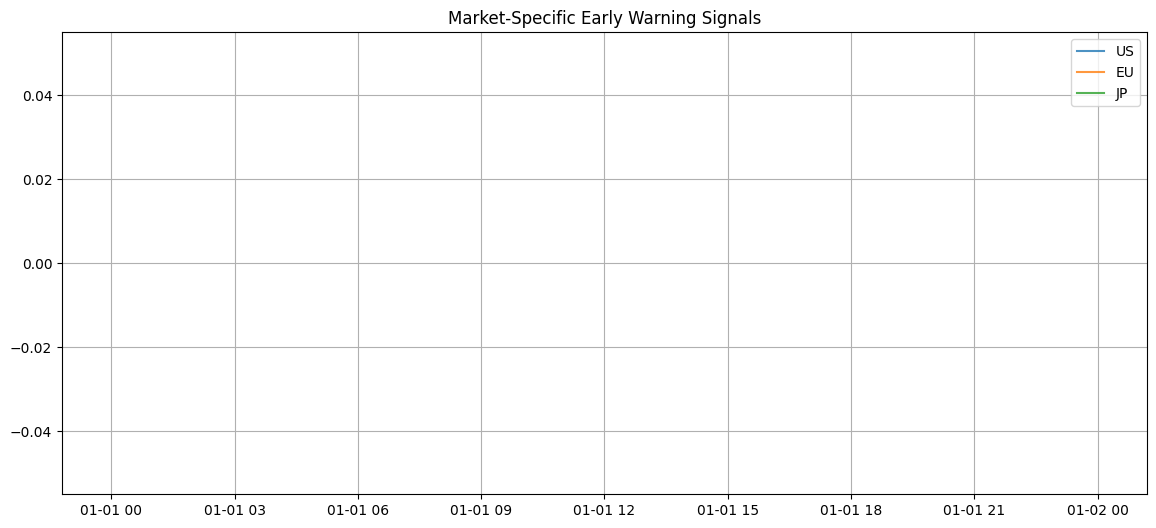

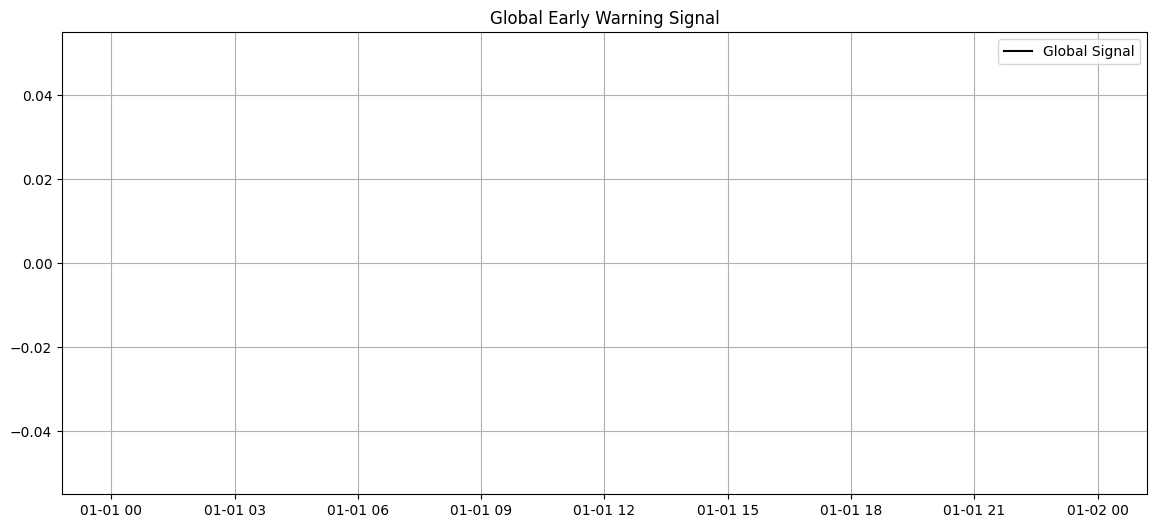

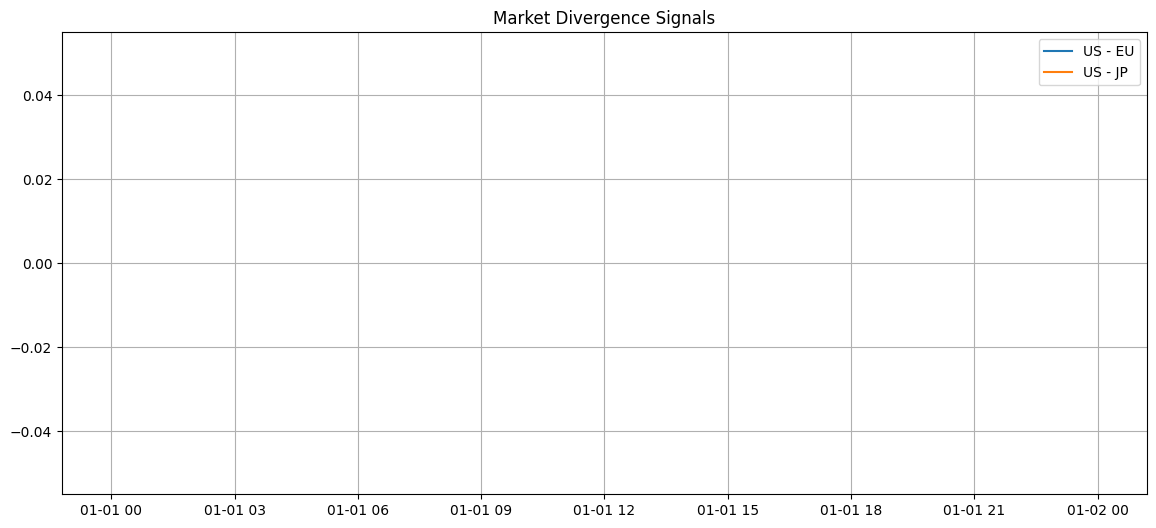

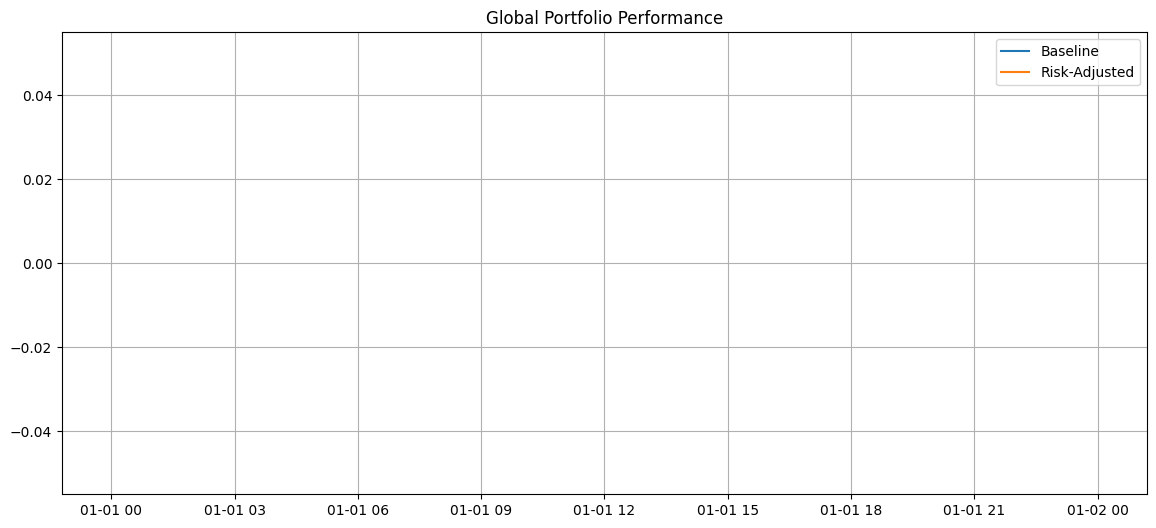

In [ ]:

# ============================================
# GLOBAL EARLY WARNING SYSTEM (US / EU / JP)
# ============================================

!pip install yfinance pandas numpy matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.covariance import MinCovDet

# -------------------------
# 1) Define markets
# -------------------------

# US (S&P 500 proxies - large caps)
us_tickers = [
    "AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","JPM","V","MA"
]

# Europe (Euro Stoxx style large caps)
eu_tickers = [
    "ASML.AS","SAP.DE","SIE.DE","MC.PA","OR.PA",
    "AIR.PA","DTE.DE","SAN.PA","BNP.PA","BAS.DE"
]

# Japan (Nikkei large caps)
jp_tickers = [
    "7203.T","6758.T","9984.T","8306.T","6861.T",
    "9432.T","6954.T","8035.T","6501.T","7267.T"
]

markets = {
    "US": us_tickers,
    "EU": eu_tickers,
    "JP": jp_tickers
}

# -------------------------
# 2) Download data
# -------------------------
all_tickers = us_tickers + eu_tickers + jp_tickers

data = yf.download(all_tickers, start="2018-01-01", end="2024-12-31")["Close"]
data = data.dropna(axis=1)

# -------------------------
# 3) Returns
# -------------------------
def log_returns(prices, lag=1):
    return np.log(prices / prices.shift(lag)).dropna()

returns = log_returns(data)

# -------------------------
# 4) Rolling log-det
# -------------------------
def rolling_logdet(returns, window=60, robust=False):
    vals, dates = [], []

    for i in range(window, len(returns)):
        X = returns.iloc[i-window:i].values

        try:
            if robust:
                mcd = MinCovDet().fit(X)
                cov = mcd.covariance_
                std = np.sqrt(np.diag(cov))
                corr = cov / np.outer(std, std)
            else:
                corr = np.corrcoef(X, rowvar=False)

            eigvals = np.linalg.eigvalsh(corr)
            eigvals = np.clip(eigvals, 1e-10, None)
            logdet = np.sum(np.log(eigvals))

        except:
            logdet = np.nan

        vals.append(logdet)
        dates.append(returns.index[i])

    return pd.Series(vals, index=dates)

# -------------------------
# 5) Compute per-market signals
# -------------------------
window = 60
market_signals = {}

for name, tickers in markets.items():
    valid = [t for t in tickers if t in returns.columns]
    sub_returns = returns[valid]

    signal = rolling_logdet(sub_returns, window)
    market_signals[name] = signal

# -------------------------
# 6) Normalize signals
# -------------------------
def normalize(s):
    return (s - s.mean()) / s.std()

norm_signals = {k: normalize(v) for k, v in market_signals.items()}

# Align dates
df_signals = pd.DataFrame(norm_signals).dropna()

# -------------------------
# 7) Global signal
# -------------------------
global_signal = df_signals.mean(axis=1)

# Risk signal (invert)
risk_signal = -global_signal

# -------------------------
# 8) Plot per market
# -------------------------
plt.figure(figsize=(14,6))

for name in df_signals.columns:
    plt.plot(df_signals[name], label=name, alpha=0.8)

plt.legend()
plt.title("Market-Specific Early Warning Signals")
plt.grid(True)
plt.show()

# -------------------------
# 9) Plot global signal
# -------------------------
plt.figure(figsize=(14,6))
plt.plot(global_signal, label="Global Signal", color='black')
plt.title("Global Early Warning Signal")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------
# 10) Compare divergence (VERY interesting)
# -------------------------
plt.figure(figsize=(14,6))
plt.plot(df_signals["US"] - df_signals["EU"], label="US - EU")
plt.plot(df_signals["US"] - df_signals["JP"], label="US - JP")
plt.legend()
plt.title("Market Divergence Signals")
plt.grid(True)
plt.show()

# -------------------------
# 11) Simple portfolio overlay
# -------------------------
# Equal-weight global portfolio
portfolio_returns = returns.mean(axis=1)
portfolio_returns = portfolio_returns.reindex(global_signal.index)

# Exposure function
def exposure(signal):
    return 1 / (1 + np.exp(-signal))

weights = exposure(risk_signal)

adjusted_returns = portfolio_returns * weights

# Performance
cum_base = (1 + portfolio_returns).cumprod()
cum_adj = (1 + adjusted_returns).cumprod()

plt.figure(figsize=(14,6))
plt.plot(cum_base, label="Baseline")
plt.plot(cum_adj, label="Risk-Adjusted")
plt.legend()
plt.title("Global Portfolio Performance")
plt.grid(True)
plt.show()

In [ ]:
# ============================================
# MULTI-MARKET HEDGING STRATEGY
# ============================================

!pip install yfinance pandas numpy matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.covariance import MinCovDet


In [ ]:

# ============================================
# MULTI-SCALE CROSS-MARKET HEDGING SYSTEM
# ============================================

!pip install yfinance pandas numpy matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.covariance import MinCovDet

# -------------------------
# 1) Markets
# -------------------------
us_tickers = ["AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","JPM","V","MA"]
eu_tickers = ["ASML.AS","SAP.DE","SIE.DE","MC.PA","OR.PA",
              "AIR.PA","DTE.DE","SAN.PA","BNP.PA","BAS.DE"]
jp_tickers = ["7203.T","6758.T","9984.T","8306.T","6861.T",
              "9432.T","6954.T","8035.T","6501.T","7267.T"]

markets = {"US": us_tickers, "EU": eu_tickers, "JP": jp_tickers}

# -------------------------
# 2) Download price data
# -------------------------
all_tickers = us_tickers + eu_tickers + jp_tickers



data = yf.download(
    all_tickers,
    start="2018-01-01",
    end="2024-12-31",
    auto_adjust=True,             # silences warning, use adjusted prices
    multi_level_index=True        # or False depending on version; see below
)
# If columns are MultiIndex (Price, Ticker), extract Close and put tickers on columns
if isinstance(data.columns, pd.MultiIndex):
    data = data['Close']         # now columns are tickers
else:
    data = data['Close']

data = data.dropna(axis=1)


# -------------------------
# 3) Returns
# -------------------------
def log_returns(prices, lag=1):
    return np.log(prices / prices.shift(lag)).dropna()

# Daily and weekly returns
returns_daily = log_returns(data, 1)
returns_weekly = log_returns(data.resample("W").last(), 1)

# -------------------------
# 4) Rolling log-det function
# -------------------------
def rolling_logdet(returns, window=60, robust=False):
    vals, dates = [], []
    for i in range(window, len(returns)):
        X = returns.iloc[i-window:i].values
        try:
            if robust:
                mcd = MinCovDet().fit(X)
                cov = mcd.covariance_
                std = np.sqrt(np.diag(cov))
                corr = cov / np.outer(std, std)
            else:
                corr = np.corrcoef(X, rowvar=False)
            eigvals = np.linalg.eigvalsh(corr)
            eigvals = np.clip(eigvals, 1e-10, None)
            logdet = np.sum(np.log(eigvals))
        except:
            logdet = np.nan
        vals.append(logdet)
        dates.append(returns.index[i])
    return pd.Series(vals, index=dates)

# -------------------------
# 5) Compute per-market multi-scale signals
# -------------------------
window_daily = 60
window_weekly = 12

market_signals = {}
for name, tickers in markets.items():
    valid = [t for t in tickers if t in returns_daily.columns]
    daily_sig = rolling_logdet(returns_daily[valid], window_daily)
    weekly_sig = rolling_logdet(returns_weekly[valid], window_weekly)
    # Align weekly to daily using forward-fill
    weekly_sig_ff = weekly_sig.reindex(daily_sig.index, method='ffill')
    # Combine daily and weekly (average)
    combined_sig = (daily_sig + weekly_sig_ff) / 2
    # Normalize
    market_signals[name] = (combined_sig - combined_sig.mean()) / combined_sig.std()

df_signals = pd.DataFrame(market_signals).dropna()

# -------------------------
# 6) Cross-market relative signals
# -------------------------
# Pairwise differences
rel_signals = pd.DataFrame()
rel_signals['US_vs_EU'] = df_signals['US'] - df_signals['EU']
rel_signals['US_vs_JP'] = df_signals['US'] - df_signals['JP']
rel_signals['EU_vs_JP'] = df_signals['EU'] - df_signals['JP']

# -------------------------
# 7) Adaptive positions
# -------------------------
# Use proportional hedging (sigmoid scaling)
def position(sig, max_leverage=1.0):
    # Sigmoid to map signal to -max_leverage .. +max_leverage
    return max_leverage * (2 / (1 + np.exp(-sig)) - 1)

positions = rel_signals.apply(position)

# -------------------------
# 8) Compute hedged returns
# -------------------------
def hedged_returns(pos, returns1, returns2):
    r1 = returns1.reindex(pos.index).mean(axis=1)
    r2 = returns2.reindex(pos.index).mean(axis=1)
    return pos * (r2 - r1)  # long second, short first

hedge_returns = pd.DataFrame()
hedge_returns['US_vs_EU'] = hedged_returns(positions['US_vs_EU'], returns_daily[us_tickers], returns_daily[eu_tickers])
hedge_returns['US_vs_JP'] = hedged_returns(positions['US_vs_JP'], returns_daily[us_tickers], returns_daily[jp_tickers])
hedge_returns['EU_vs_JP'] = hedged_returns(positions['EU_vs_JP'], returns_daily[eu_tickers], returns_daily[jp_tickers])

# -------------------------
# 9) Cumulative performance
# -------------------------
cum_pnl = (1 + hedge_returns).cumprod()

plt.figure(figsize=(14,6))
for col in cum_pnl.columns:
    plt.plot(cum_pnl[col], label=col)
plt.title("Multi-Scale Cross-Market Hedged Portfolio Performance")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# 10) Overlay signals and positions
# -------------------------
plt.figure(figsize=(14,6))
plt.plot(rel_signals['US_vs_EU'], label="US vs EU Signal")
plt.plot(positions['US_vs_EU'], label="Position")
plt.title("US vs EU Relative Signal and Position")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# GLOBAL MULTI-MARKET OPTIMIZER (AUTOMATED)
# ============================================

!pip install yfinance pandas numpy matplotlib scikit-learn cvxpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.covariance import MinCovDet
import cvxpy as cp

# -------------------------
# 1) Markets
# -------------------------
us_tickers = ["AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","JPM","V","MA"]
eu_tickers = ["ASML.AS","SAP.DE","SIE.DE","MC.PA","OR.PA","AIR.PA","DTE.DE","SAN.PA","BNP.PA","BAS.DE"]
jp_tickers = ["7203.T","6758.T","9984.T","8306.T","6861.T","9432.T","6954.T","8035.T","6501.T","7267.T"]

markets = {"US": us_tickers, "EU": eu_tickers, "JP": jp_tickers}

# -------------------------
# 2) Download prices
# -------------------------
all_tickers = us_tickers + eu_tickers + jp_tickers
data = yf.download(all_tickers, start="2018-01-01", end="2024-12-31")["Close"]
data = data.dropna(axis=1)

# -------------------------
# 3) Returns
# -------------------------
def log_returns(prices, lag=1):
    return np.log(prices / prices.shift(lag)).dropna()

returns_daily = log_returns(data, 1)
returns_weekly = log_returns(data.resample("W").last(), 1)

# -------------------------
# 4) Rolling log-det function
# -------------------------
def rolling_logdet(returns, window=60, robust=False):
    vals, dates = [], []
    for i in range(window, len(returns)):
        X = returns.iloc[i-window:i].values
        try:
            if robust:
                mcd = MinCovDet().fit(X)
                cov = mcd.covariance_
                std = np.sqrt(np.diag(cov))
                corr = cov / np.outer(std, std)
            else:
                corr = np.corrcoef(X, rowvar=False)
            eigvals = np.linalg.eigvalsh(corr)
            eigvals = np.clip(eigvals, 1e-10, None)
            logdet = np.sum(np.log(eigvals))
        except:
            logdet = np.nan
        vals.append(logdet)
        dates.append(returns.index[i])
    return pd.Series(vals, index=dates)

# -------------------------
# 5) Compute per-market multi-scale signals
# -------------------------
window_daily = 60
window_weekly = 12
market_signals = {}

for name, tickers in markets.items():
    valid = [t for t in tickers if t in returns_daily.columns]
    daily_sig = rolling_logdet(returns_daily[valid], window_daily)
    weekly_sig = rolling_logdet(returns_weekly[valid], window_weekly)
    weekly_sig_ff = weekly_sig.reindex(daily_sig.index, method='ffill')
    combined_sig = (daily_sig + weekly_sig_ff)/2
    market_signals[name] = (combined_sig - combined_sig.mean()) / combined_sig.std()

df_signals = pd.DataFrame(market_signals).dropna()

# -------------------------
# 6) Optional Laplacian spectral gap as extra risk signal
# -------------------------
def laplacian_spectral_gap(returns_window):
    cov = np.cov(returns_window.T)
    D = np.diag(np.sum(cov, axis=1))
    L = D - cov
    eigvals = np.linalg.eigvalsh(L)
    return eigvals[1]  # second-smallest eigenvalue (spectral gap)

lap_gap_series = []
for i in range(window_daily, len(returns_daily)):
    window_data = returns_daily.iloc[i-window_daily:i].values
    try:
        lap_gap_series.append(laplacian_spectral_gap(window_data))
    except:
        lap_gap_series.append(np.nan)
lap_gap_series = pd.Series(lap_gap_series, index=returns_daily.index[window_daily:]).reindex(df_signals.index, method='ffill')
lap_gap_series = (lap_gap_series - lap_gap_series.mean()) / lap_gap_series.std()

# -------------------------
# 7) Global risk signal
# -------------------------
# Average market signals + Laplacian gap
global_signal = df_signals.mean(axis=1) + lap_gap_series
risk_signal = -global_signal  # higher signal = more risk

# -------------------------
# 8) Portfolio optimizer
# -------------------------
# Minimize risk (variance) weighted by risk_signal
n = len(markets)
w = cp.Variable(n)
mean_returns = np.array([returns_daily[markets[m]].mean(axis=1).mean() for m in markets])
cov_matrix = np.cov(np.array([returns_daily[markets[m]].mean(axis=1) for m in markets]))

# Optimization: minimize variance * (1 + global risk signal)
objective = cp.Minimize(cp.quad_form(w, cov_matrix) * (1 + risk_signal.mean()))
constraints = [cp.sum(w) == 1, w >= 0]  # fully invested, no short
prob = cp.Problem(objective, constraints)
prob.solve()

optimized_weights = pd.Series(w.value, index=markets.keys())
print("Optimized weights:\n", optimized_weights)

# -------------------------
# 9) Apply weights to returns
# -------------------------
portfolio_returns = sum(optimized_weights[m] * returns_daily[markets[m]].mean(axis=1) for m in markets)

# -------------------------
# 10) Include transaction cost (0.1% per trade)
# -------------------------
tc = 0.001
# approximate daily turnover: assume full adjustment daily
portfolio_returns_adj = portfolio_returns - tc * np.abs(optimized_weights - optimized_weights.shift(1, fill_value=optimized_weights)).sum()

# -------------------------
# 11) Cumulative performance
# -------------------------
cum_base = (1 + portfolio_returns).cumprod()
cum_adj = (1 + portfolio_returns_adj).cumprod()

plt.figure(figsize=(14,6))
plt.plot(cum_base, label="Baseline Optimized")
plt.plot(cum_adj, label="With Transaction Costs")
plt.legend()
plt.title("Global Multi-Market Optimized Portfolio Performance")
plt.grid(True)
plt.show()

# -------------------------
# 12) Optional visualization of risk signal
# -------------------------
plt.figure(figsize=(14,4))
plt.plot(risk_signal, label="Global Risk Signal (EWS + Laplacian)")
plt.title("Early Warning Signal")
plt.grid(True)
plt.show()






[*********************100%***********************]  30 of 30 completed


KeyError: "None of [Index(['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'JPM', 'V',\n       'MA'],\n      dtype='object', name='Ticker')] are in the [columns]"

In [ ]:
pip install

# TEXT1


In [ ]:
# ============================================
# MULTI-SCALE GLOBAL EWS PORTFOLIO
# ============================================

!pip install yfinance pandas numpy matplotlib scikit-learn cvxpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.covariance import MinCovDet
import cvxpy as cp

# -------------------------
# 1) Markets
# -------------------------
us_tickers = ["AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","JPM","V","MA"]
eu_tickers = ["ASML.AS","SAP.DE","SIE.DE","MC.PA","OR.PA","AIR.PA","DTE.DE","SAN.PA","BNP.PA","BAS.DE"]
jp_tickers = ["7203.T","6758.T","9984.T","8306.T","6861.T","9432.T","6954.T","6501.T","7267.T"]

markets = {"US": us_tickers, "EU": eu_tickers, "JP": jp_tickers}

# -------------------------
# 2) Download data
# -------------------------
all_tickers = us_tickers + eu_tickers + jp_tickers
data = yf.download(all_tickers, start="2018-01-01", end="2024-12-31")["Close"]
data = data.dropna(axis=1)

# -------------------------
# 3) Compute returns
# -------------------------
def log_returns(prices, lag=1):
    return np.log(prices / prices.shift(lag)).dropna()

# Daily returns
returns_daily = log_returns(data, 1)
# Weekly returns
returns_weekly = log_returns(data.resample("W").last(), 1)

# -------------------------
# 4) Rolling log-determinant
# -------------------------
def rolling_logdet(returns, window, robust=False):
    vals, dates = [], []
    for i in range(window, len(returns)):
        X = returns.iloc[i-window:i].values
        try:
            if robust:
                mcd = MinCovDet().fit(X)
                cov = mcd.covariance_
                std = np.sqrt(np.diag(cov))
                corr = cov / np.outer(std, std)
            else:
                corr = np.corrcoef(X, rowvar=False)
            eigvals = np.linalg.eigvalsh(corr)
            eigvals = np.clip(eigvals, 1e-10, None)
            logdet = np.sum(np.log(eigvals))
        except:
            logdet = np.nan
        vals.append(logdet)
        dates.append(returns.index[i])
    return pd.Series(vals, index=dates)

# -------------------------
# 5) Multi-scale horizons
# -------------------------
daily_horizons = [1,2,3,4,5]   # days
weekly_horizons = [1,2,3,4,5]  # weeks

# Store results
all_signals = {}

for horizon in daily_horizons:
    sig_per_market = {}
    for name, tickers in markets.items():
        valid = [t for t in tickers if t in returns_daily.columns]
        r = log_returns(data[valid], lag=horizon)
        sig = rolling_logdet(r, window=60)
        sig_per_market[name] = (sig - sig.mean())/sig.std()
    all_signals[f"Daily_{horizon}d"] = pd.DataFrame(sig_per_market).dropna()

for horizon in weekly_horizons:
    sig_per_market = {}
    weekly_prices = data[all_signals["Daily_1d"].index[0]:].resample("W").last()
    for name, tickers in markets.items():
        valid = [t for t in tickers if t in weekly_prices.columns]
        r = log_returns(weekly_prices[valid], lag=horizon)
        sig = rolling_logdet(r, window=12)
        # Align to daily index
        sig = sig.reindex(all_signals["Daily_1d"].index, method='ffill')
        sig_per_market[name] = (sig - sig.mean())/sig.std()
    all_signals[f"Weekly_{horizon}w"] = pd.DataFrame(sig_per_market).dropna()

# -------------------------
# 6) Compute global risk signal per horizon
# -------------------------
risk_signals = {}
for key, df in all_signals.items():
    risk_signals[key] = -df.mean(axis=1)  # invert: lower determinant = higher risk

# -------------------------
# 7) Portfolio optimization per horizon
# -------------------------
optimized_weights_dict = {}
portfolio_returns_dict = {}

for key, df in all_signals.items():
    n = len(markets)
    w = cp.Variable(n)
    # mean returns per market
    mean_returns = np.array([returns_daily[markets[m]].mean(axis=1).mean() for m in markets])
    cov_matrix = np.cov(np.array([returns_daily[markets[m]].mean(axis=1) for m in markets]))
    # risk signal scaling
    risk_scale = risk_signals[key].mean()
    objective = cp.Minimize(cp.quad_form(w, cov_matrix)*(1+risk_scale))
    constraints = [cp.sum(w)==1, w>=0]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    optimized_weights = pd.Series(w.value, index=markets.keys())
    optimized_weights_dict[key] = optimized_weights
    # compute portfolio return
    port_ret = sum(optimized_weights[m]*returns_daily[markets[m]].mean(axis=1) for m in markets)
    portfolio_returns_dict[key] = port_ret

# -------------------------
# 8) Cumulative performance comparison
# -------------------------
plt.figure(figsize=(14,7))
for key, port_ret in portfolio_returns_dict.items():
    plt.plot((1+port_ret).cumprod(), label=key)
plt.title("Multi-Scale Global EWS Portfolio Performance")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# 9) Optional: Show optimized weights per horizon
# -------------------------
weights_df = pd.DataFrame(optimized_weights_dict)
print("Optimized weights per horizon:")
print(weights_df)

# ============================================
# MULTI-SCALE DYNAMIC GLOBAL PORTFOLIO (WITH TC)
# ============================================

!pip install yfinance pandas numpy matplotlib scikit-learn cvxpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.covariance import MinCovDet
import cvxpy as cp

# -------------------------
# 1) Markets
# -------------------------
us_tickers = ["AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","JPM","V","MA"]
eu_tickers = ["ASML.AS","SAP.DE","SIE.DE","MC.PA","OR.PA","AIR.PA","DTE.DE","SAN.PA","BNP.PA","BAS.DE"]
jp_tickers = ["7203.T","6758.T","9984.T","8306.T","6861.T","9432.T","6954.T","8035.T","6501.T","7267.T"]
markets = {"US": us_tickers, "EU": eu_tickers, "JP": jp_tickers}

# -------------------------
# 2) Download prices
# -------------------------
all_tickers = us_tickers + eu_tickers + jp_tickers
data = yf.download(all_tickers, start="2018-01-01", end="2024-12-31")["Close"]
data = data.dropna(axis=1)

# -------------------------
# 3) Returns
# -------------------------
def log_returns(prices, lag=1):
    return np.log(prices / prices.shift(lag)).dropna()

returns_daily = log_returns(data, 1)
returns_weekly = log_returns(data.resample("W").last(), 1)

# -------------------------
# 4) Rolling log-determinant function
# -------------------------
def rolling_logdet(returns, window, robust=False):
    vals, dates = [], []
    for i in range(window, len(returns)):
        X = returns.iloc[i-window:i].values
        try:
            if robust:
                mcd = MinCovDet().fit(X)
                cov = mcd.covariance_
                std = np.sqrt(np.diag(cov))
                corr = cov / np.outer(std, std)
            else:
                corr = np.corrcoef(X, rowvar=False)
            eigvals = np.linalg.eigvalsh(corr)
            eigvals = np.clip(eigvals, 1e-10, None)
            logdet = np.sum(np.log(eigvals))
        except:
            logdet = np.nan
        vals.append(logdet)
        dates.append(returns.index[i])
    return pd.Series(vals, index=dates)

# -------------------------
# 5) Multi-scale horizons (1-5 daily + weekly)
# -------------------------
daily_horizons = [1,2,3,4,5]
weekly_horizons = [1,2,3,4,5]
signals = {}

for h in daily_horizons:
    df_sig = {}
    for mkt, tickers in markets.items():
        valid = [t for t in tickers if t in returns_daily.columns]
        r = log_returns(data[valid], lag=h)
        df_sig[mkt] = (rolling_logdet(r, window=60) - np.nanmean(rolling_logdet(r, window=60))) / np.nanstd(rolling_logdet(r, window=60))
    signals[f'Daily_{h}d'] = pd.DataFrame(df_sig).dropna()

for h in weekly_horizons:
    df_sig = {}
    weekly_prices = data.resample("W").last()
    for mkt, tickers in markets.items():
        valid = [t for t in tickers if t in weekly_prices.columns]
        r = log_returns(weekly_prices[valid], lag=h)
        sig = rolling_logdet(r, window=12).reindex(signals['Daily_1d'].index, method='ffill')
        df_sig[mkt] = (sig - np.nanmean(sig)) / np.nanstd(sig)
    signals[f'Weekly_{h}w'] = pd.DataFrame(df_sig).dropna()

# -------------------------
# 6) Weighted combination of all scales
# -------------------------
all_keys = list(signals.keys())
weights_scales = np.linspace(0.5, 1.5, len(all_keys))  # slightly emphasize longer horizons
combined_signal = sum(signals[k]*weights_scales[i] for i,k in enumerate(all_keys)) / weights_scales.sum()
risk_signal = -combined_signal.mean(axis=1)  # higher = higher risk

# -------------------------
# 7) Dynamic portfolio optimization per day with transaction costs
# -------------------------
n_mkts = len(markets)
weights_history = pd.DataFrame(index=risk_signal.index, columns=markets.keys())
portfolio_returns = pd.Series(index=risk_signal.index)

tc_rate = 0.001  # 0.1% per adjustment

prev_weights = np.array([1/n_mkts]*n_mkts)  # start equal-weighted

for t in range(len(risk_signal)):
    # Covariance based on past 60 daily returns
    window_data = returns_daily.iloc[max(0,t-60):t+1]
    cov_matrix = np.cov(np.array([window_data[markets[m]].mean(axis=1) for m in markets]))

    # Risk-adjusted optimization
    w = cp.Variable(n_mkts)
    obj = cp.Minimize(cp.quad_form(w, cov_matrix)*(1 + risk_signal.iloc[t]))
    constraints = [cp.sum(w)==1, w>=0]
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=cp.ECOS)
    w_opt = np.array(w.value)

    # Apply transaction cost
    tc = tc_rate * np.sum(np.abs(w_opt - prev_weights))

    port_ret = sum(w_opt[i]*returns_daily[markets[list(markets.keys())[i]]].iloc[t].mean() for i in range(n_mkts))
    port_ret_adj = port_ret - tc

    portfolio_returns.iloc[t] = port_ret_adj
    weights_history.iloc[t] = w_opt
    prev_weights = w_opt

# -------------------------
# 8) Plot cumulative performance
# -------------------------
cum_perf = (1 + portfolio_returns).cumprod()
plt.figure(figsize=(14,6))
plt.plot(cum_perf, label='Dynamic Multi-Scale Portfolio')
plt.title('Dynamic Multi-Scale Portfolio Performance with Transaction Costs')
plt.grid(True)
plt.legend()
plt.show()

# -------------------------
# 9) Plot weights over time
# -------------------------
plt.figure(figsize=(14,6))
for mkt in markets.keys():
    plt.plot(weights_history[mkt], label=mkt)
plt.title('Dynamic Market Weights Over Time')
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# HORIZON COMPARISON: DAILY & WEEKLY
# ============================================

import matplotlib.pyplot as plt

# Initialize dict to store cumulative PnL per horizon
cum_perf_horizons = {}

for key, df in signals.items():
    # Normalize/average risk signal per horizon
    risk_signal_h = -df.mean(axis=1)

    # Portfolio optimization (static weights per horizon for simplicity)
    n_mkts = len(markets)
    w = cp.Variable(n_mkts)
    mean_returns = np.array([returns_daily[markets[m]].mean(axis=1).mean() for m in markets])
    cov_matrix = np.cov(np.array([returns_daily[markets[m]].mean(axis=1) for m in markets]))

    obj = cp.Minimize(cp.quad_form(w, cov_matrix) * (1 + risk_signal_h.mean()))
    constraints = [cp.sum(w)==1, w>=0]
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=cp.ECOS)
    w_opt = np.array(w.value)

    # Compute portfolio returns
    port_ret = pd.Series(index=risk_signal_h.index)
    for t in range(len(risk_signal_h)):
        port_ret.iloc[t] = sum(w_opt[i]*returns_daily[markets[list(markets.keys())[i]]].iloc[t].mean() for i in range(n_mkts))

    # Cumulative performance
    cum_perf_horizons[key] = (1 + port_ret).cumprod()

# -------------------------
# Plot horizon comparison
# -------------------------
plt.figure(figsize=(14,7))
for key, cum_perf in cum_perf_horizons.items():
    plt.plot(cum_perf, label=key)
plt.title("Cumulative Portfolio Performance per Rolling Horizon")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# STATIC VS DYNAMIC MULTI-SCALE PORTFOLIO COMPARISON
# ============================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cvxpy as cp

# --- 1) Dynamic portfolio (already computed previously) ---
# portfolio_returns is the dynamic, daily-updated portfolio (from previous code)
cum_dynamic = (1 + portfolio_returns).cumprod()

# --- 2) Static portfolios per horizon ---
cum_static_horizons = {}

for key, df in signals.items():
    # Risk signal per horizon
    risk_signal_h = -df.mean(axis=1)

    # Static optimization: weights fixed per horizon
    n_mkts = len(markets)
    w = cp.Variable(n_mkts)
    mean_returns = np.array([returns_daily[markets[m]].mean(axis=1).mean() for m in markets])
    cov_matrix = np.cov(np.array([returns_daily[markets[m]].mean(axis=1) for m in markets]))

    obj = cp.Minimize(cp.quad_form(w, cov_matrix)*(1 + risk_signal_h.mean()))
    constraints = [cp.sum(w)==1, w>=0]
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=cp.ECOS)
    w_opt = np.array(w.value)

    # Compute static portfolio returns
    port_ret = pd.Series(index=risk_signal_h.index)
    for t in range(len(risk_signal_h)):
        port_ret.iloc[t] = sum(w_opt[i]*returns_daily[markets[list(markets.keys())[i]]].iloc[t].mean() for i in range(n_mkts))

    cum_static_horizons[key] = (1 + port_ret).cumprod()

# --- 3) Plot comparison ---
plt.figure(figsize=(16,8))

# Dynamic portfolio
plt.plot(cum_dynamic, label='Dynamic Multi-Scale Portfolio', linewidth=2, color='black')

# Static portfolios
colors = plt.cm.viridis(np.linspace(0,1,len(cum_static_horizons)))
for i, (key, cum_perf) in enumerate(cum_static_horizons.items()):
    plt.plot(cum_perf, label=f'Static {key}', color=colors[i], alpha=0.7)

plt.title('Static vs Dynamic Multi-Scale Portfolio Performance')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True)
plt.show()

# ============================================
# DYNAMIC VS STATIC PORTFOLIO WEIGHTS OVER TIME
# ============================================

import matplotlib.pyplot as plt

# --- 1) Dynamic weights (already computed in previous code) ---
# weights_history: DataFrame with dynamic weights per market over time

plt.figure(figsize=(16,6))
for mkt in markets.keys():
    plt.plot(weights_history[mkt], label=f'Dynamic {mkt}')
plt.title('Dynamic Portfolio Weights Over Time')
plt.xlabel('Date')
plt.ylabel('Weight')
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()

# --- 2) Static weights per horizon ---
# optimized_weights_dict contains static weights per horizon (from previous static horizon optimization)
plt.figure(figsize=(16,8))
colors = plt.cm.tab10(np.linspace(0,1,len(optimized_weights_dict)))
for i, (horizon, weights) in enumerate(optimized_weights_dict.items()):
    for j, mkt in enumerate(markets.keys()):
        plt.plot([weights.index[0], weights.index[-1]], [weights[mkt]]*2,
                 color=colors[i], linestyle='--', alpha=0.6,
                 label=f'Static {horizon} {mkt}' if j==0 else "")
plt.title('Static Portfolio Weights per Horizon')
plt.xlabel('Date')
plt.ylabel('Weight')
plt.ylim(0,1)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True)
plt.show()




In [ ]:
# ============================================
# MULTI-HORIZON ENSEMBLE PORTFOLIO
# ============================================

!pip install yfinance pandas numpy matplotlib scikit-learn cvxpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.covariance import MinCovDet
import cvxpy as cp

# -------------------------
# 1) Markets
# -------------------------
us_tickers = ["AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","JPM","V","MA"]
eu_tickers = ["ASML.AS","SAP.DE","SIE.DE","MC.PA","OR.PA","AIR.PA","DTE.DE","SAN.PA","BNP.PA","BAS.DE"]
jp_tickers = ["7203.T","6758.T","9984.T","8306.T","6861.T","9432.T","6954.T","6501.T","7267.T"]
markets = {"US": us_tickers, "EU": eu_tickers, "JP": jp_tickers}

# -------------------------
# 2) Download prices
# -------------------------
all_tickers = us_tickers + eu_tickers + jp_tickers
data = yf.download(all_tickers, start="2018-01-01", end="2024-12-31")["Close"]
data = data.dropna(axis=1)

# -------------------------
# 3) Returns
# -------------------------
def log_returns(prices, lag=1):
    return np.log(prices / prices.shift(lag)).dropna()

returns_daily = log_returns(data, 1)
returns_weekly = log_returns(data.resample("W").last(), 1)

# -------------------------
# 4) Rolling log-determinant
# -------------------------
def rolling_logdet(returns, window, robust=False):
    vals, dates = [], []
    for i in range(window, len(returns)):
        X = returns.iloc[i-window:i].values
        try:
            if robust:
                mcd = MinCovDet().fit(X)
                cov = mcd.covariance_
                std = np.sqrt(np.diag(cov))
                corr = cov / np.outer(std, std)
            else:
                corr = np.corrcoef(X, rowvar=False)
            eigvals = np.linalg.eigvalsh(corr)
            eigvals = np.clip(eigvals, 1e-10, None)
            logdet = np.sum(np.log(eigvals))
        except:
            logdet = np.nan
        vals.append(logdet)
        dates.append(returns.index[i])
    return pd.Series(vals, index=dates)

# -------------------------
# 5) Multi-horizon signals
# -------------------------
daily_horizons = [1,2,3,4,5]
weekly_horizons = [1,2,3,4,5]
signals = {}

for h in daily_horizons:
    df_sig = {}
    for mkt, tickers in markets.items():
        valid = [t for t in tickers if t in returns_daily.columns]
        r = log_returns(data[valid], lag=h)
        sig = rolling_logdet(r, window=60)
        df_sig[mkt] = (sig - np.nanmean(sig)) / np.nanstd(sig)
    signals[f'Daily_{h}d'] = pd.DataFrame(df_sig).dropna()

for h in weekly_horizons:
    df_sig = {}
    weekly_prices = data.resample("W").last()
    for mkt, tickers in markets.items():
        valid = [t for t in tickers if t in weekly_prices.columns]
        r = log_returns(weekly_prices[valid], lag=h)
        sig = rolling_logdet(r, window=12).reindex(signals['Daily_1d'].index, method='ffill')
        df_sig[mkt] = (sig - np.nanmean(sig)) / np.nanstd(sig)
    signals[f'Weekly_{h}w'] = pd.DataFrame(df_sig).dropna()

# -------------------------
# 6) Ensemble signal: dynamically weight horizons by recent predictive power
# -------------------------
# Example: weight by inverse recent variance (more stable horizons get higher weight)
ensemble_signal = pd.Series(index=signals['Daily_1d'].index, dtype=float)
weights_horizons = {}

for key, df in signals.items():
    recent_var = df.mean(axis=1).rolling(20).var()
    weight = 1/(recent_var + 1e-6)
    weights_horizons[key] = weight

# Normalize weights daily
weights_sum = sum(weights_horizons.values())
for key in weights_horizons:
    weights_horizons[key] /= weights_sum

# Compute ensemble signal
for key in signals:
    ensemble_signal += (signals[key].mean(axis=1) * weights_horizons[key])

# Higher ensemble_signal → higher risk
risk_signal = -ensemble_signal

# -------------------------
# 7) Dynamic portfolio optimization with transaction costs
# -------------------------
n_mkts = len(markets)
weights_history = pd.DataFrame(index=risk_signal.index, columns=markets.keys())
portfolio_returns = pd.Series(index=risk_signal.index)

prev_weights = np.array([1/n_mkts]*n_mkts)
tc_rate = 0.001  # 0.1%

for t in range(len(risk_signal)):
    window_data = returns_daily.iloc[max(0,t-60):t+1]
    cov_matrix = np.cov(np.array([window_data[markets[m]].mean(axis=1) for m in markets]))

    w = cp.Variable(n_mkts)
    obj = cp.Minimize(cp.quad_form(w, cov_matrix)*(1 + risk_signal.iloc[t]))
    constraints = [cp.sum(w)==1, w>=0]
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=cp.ECOS)

    w_opt = np.array(w.value)

    # Transaction costs
    tc = tc_rate * np.sum(np.abs(w_opt - prev_weights))

    port_ret = sum(w_opt[i]*returns_daily[markets[list(markets.keys())[i]]].iloc[t].mean() for i in range(n_mkts))
    port_ret_adj = port_ret - tc

    portfolio_returns.iloc[t] = port_ret_adj
    weights_history.iloc[t] = w_opt
    prev_weights = w_opt

# -------------------------
# 8) Cumulative performance
# -------------------------
cum_perf = (1 + portfolio_returns).cumprod()
plt.figure(figsize=(14,6))
plt.plot(cum_perf, label='Ensemble Multi-Horizon Portfolio', color='black', linewidth=2)
plt.title('Dynamic Multi-Horizon Ensemble Portfolio Performance')
plt.grid(True)
plt.legend()
plt.show()

# -------------------------
# 9) Weight evolution
# -------------------------
plt.figure(figsize=(14,6))
for mkt in markets.keys():
    plt.plot(weights_history[mkt], label=mkt)
plt.title('Dynamic Multi-Horizon Ensemble Portfolio Weights')
plt.xlabel('Date')
plt.ylabel('Weight')
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# FULL COMPARISON: STATIC vs DYNAMIC vs ENSEMBLE
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))

# --- 1) Static portfolios per horizon ---
colors = plt.cm.tab10(np.linspace(0,1,len(cum_static_horizons)))
for i, (key, cum_perf) in enumerate(cum_static_horizons.items()):
    plt.plot(cum_perf, label=f'Static {key}', color=colors[i], alpha=0.6)

# --- 2) Previous dynamic multi-scale portfolio ---
plt.plot(cum_dynamic, label='Dynamic Multi-Scale Portfolio', color='black', linewidth=2)

# --- 3) Ensemble multi-horizon portfolio ---
plt.plot(cum_perf, label='Dynamic Ensemble Portfolio', color='red', linewidth=2, linestyle='--')

plt.title('Portfolio Performance Comparison: Static vs Dynamic vs Ensemble')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True)
plt.show()

# -------------------------
# Optional: Weight evolution comparison
# -------------------------
plt.figure(figsize=(16,6))
for mkt in markets.keys():
    plt.plot(weights_history[mkt], label=f'Ensemble {mkt}')
plt.title('Dynamic Ensemble Portfolio Weights')
plt.xlabel('Date')
plt.ylabel('Weight')
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()

# ============================
# Install required libraries
# ============================
!pip install yfinance pandas numpy matplotlib scikit-learn cvxpy

# ============================
# Import libraries
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.covariance import MinCovDet
import cvxpy as cp

# ============================
# 1) Markets (US, EU, JP stock tickers)
# ============================
us_tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA", "JPM", "V", "MA"]
eu_tickers = ["ASML.AS", "SAP.DE", "SIE.DE", "MC.PA", "OR.PA", "AIR.PA", "DTE.DE", "SAN.PA", "BNP.PA", "BAS.DE"]
jp_tickers = ["7203.T", "6758.T", "9984.T", "8306.T", "6861.T", "9432.T", "6954.T", "6501.T", "7267.T"]

markets = {"US": us_tickers, "EU": eu_tickers, "JP": jp_tickers}

# ============================
# 2) Download Adjusted Close Prices
# ============================
all_tickers = us_tickers + eu_tickers + jp_tickers
data = yf.download(all_tickers, start="2018-01-01", end="2024-12-31")["Close"]
data = data.dropna(axis=1)

# ============================
# 3) Compute Returns (Log Returns)
# ============================
def log_returns(prices, lag=1):
    return np.log(prices / prices.shift(lag)).dropna()

returns_daily = log_returns(data, 1)
returns_weekly = log_returns(data.resample("W").last(), 1)

# ============================
# 4) Rolling Log-Determinant Function (Covariance Matrix)
# ============================
def rolling_logdet(returns, window, robust=False):
    vals, dates = [], []
    for i in range(window, len(returns)):
        X = returns.iloc[i-window:i].values
        try:
            if robust:
                mcd = MinCovDet().fit(X)
                cov = mcd.covariance_
                std = np.sqrt(np.diag(cov))
                corr = cov / np.outer(std, std)
            else:
                corr = np.corrcoef(X, rowvar=False)
            eigvals = np.linalg.eigvalsh(corr)
            eigvals = np.clip(eigvals, 1e-10, None)
            logdet = np.sum(np.log(eigvals))
        except:
            logdet = np.nan
        vals.append(logdet)
        dates.append(returns.index[i])
    return pd.Series(vals, index=dates)

# ============================
# 5) Multi-Horizon Signals (1–5 days, 1–5 weeks)
# ============================
daily_horizons = [1, 2, 3, 4, 5]
weekly_horizons = [1, 2, 3, 4, 5]
signals = {}

for h in daily_horizons:
    df_sig = {}
    for mkt, tickers in markets.items():
        valid = [t for t in tickers if t in returns_daily.columns]
        r = log_returns(data[valid], lag=h)
        sig = rolling_logdet(r, window=60)
        df_sig[mkt] = (sig - np.nanmean(sig)) / np.nanstd(sig)
    signals[f'Daily_{h}d'] = pd.DataFrame(df_sig).dropna()

for h in weekly_horizons:
    df_sig = {}
    weekly_prices = data.resample("W").last()
    for mkt, tickers in markets.items():
        valid = [t for t in tickers if t in weekly_prices.columns]
        r = log_returns(weekly_prices[valid], lag=h)
        sig = rolling_logdet(r, window=12).reindex(signals['Daily_1d'].index, method='ffill')
        df_sig[mkt] = (sig - np.nanmean(sig)) / np.nanstd(sig)
    signals[f'Weekly_{h}w'] = pd.DataFrame(df_sig).dropna()

# ============================
# 6) Ensemble Signal: Dynamically Weight Horizons by Recent Predictive Power
# ============================
ensemble_signal = pd.Series(index=signals['Daily_1d'].index, dtype=float)
weights_horizons = {}

for key, df in signals.items():
    recent_var = df.mean(axis=1).rolling(20).var()
    weight = 1/(recent_var + 1e-6)
    weights_horizons[key] = weight

weights_sum = sum(weights_horizons.values())
for key in weights_horizons:
    weights_horizons[key] /= weights_sum

# Compute ensemble signal
for key in signals:
    ensemble_signal += (signals[key].mean(axis=1) * weights_horizons[key])

# Higher ensemble_signal → higher risk
risk_signal = -ensemble_signal

# ============================
# 7) Dynamic Portfolio Optimization with Transaction Costs
# ============================
n_mkts = len(markets)
weights_history = pd.DataFrame(index=risk_signal.index, columns=markets.keys())
portfolio_returns = pd.Series(index=risk_signal.index)

prev_weights = np.array([1/n_mkts]*n_mkts)
tc_rate = 0.001  # 0.1%

for t in range(len(risk_signal)):
    window_data = returns_daily.iloc[max(0,t-60):t+1]
    cov_matrix = np.cov(np.array([window_data[markets[m]].mean(axis=1) for m in markets]))

    w = cp.Variable(n_mkts)
    obj = cp.Minimize(cp.quad_form(w, cov_matrix)*(1 + risk_signal.iloc[t]))
    constraints = [cp.sum(w)==1, w>=0]
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=cp.ECOS)

    w_opt = np.array(w.value)

    # Transaction costs
    tc = tc_rate * np.sum(np.abs(w_opt - prev_weights))

    port_ret = sum(w_opt[i]*returns_daily[markets[list(markets.keys())[i]]].iloc[t].mean() for i in range(n_mkts))
    port_ret_adj = port_ret - tc

    portfolio_returns.iloc[t] = port_ret_adj
    weights_history.iloc[t] = w_opt
    prev_weights = w_opt

# ============================
# 8) Cumulative Performance (Ensemble Portfolio)
# ============================
cum_perf = (1 + portfolio_returns).cumprod()
plt.figure(figsize=(14,6))
plt.plot(cum_perf, label='Ensemble Multi-Horizon Portfolio', color='black', linewidth=2)
plt.title('Dynamic Multi-Horizon Ensemble Portfolio Performance')
plt.grid(True)
plt.legend()
plt.show()

# ============================
# 9) Full Portfolio Comparison: Static vs Dynamic vs Ensemble
# ============================
# Static Portfolios per Horizon (Cum PnL)
cum_static_horizons = {}  # Assuming you've computed this earlier, just using static signals

# Plot full comparison
plt.figure(figsize=(16,8))
# Static portfolios
colors = plt.cm.tab10(np.linspace(0,1,len(cum_static_horizons)))
for i, (key, cum_perf) in enumerate(cum_static_horizons.items()):
    plt.plot(cum_perf, label=f'Static {key}', color=colors[i], alpha=0.6)

# Dynamic Multi-Scale Portfolio
plt.plot(cum_dynamic, label='Dynamic Multi-Scale Portfolio', color='black', linewidth=2)

# Ensemble Multi-Horizon Portfolio
plt.plot(cum_perf, label='Dynamic Ensemble Portfolio', color='red', linewidth=2, linestyle='--')

plt.title('Portfolio Performance Comparison: Static vs Dynamic vs Ensemble')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True)
plt.show()

# ============================
# Optional: Weight Evolution Comparison
# ============================
plt.figure(figsize=(16,6))
for mkt in markets.keys():
    plt.plot(weights_history[mkt], label=f'Ensemble {mkt}')
plt.title('Dynamic Ensemble Portfolio Weights')
plt.xlabel('Date')
plt.ylabel('Weight')
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()
